In [1]:
from preprocessing import get_data, get_encoded_data, split_data, create_features

features, target = get_data()
features = create_features(features)
encoded_features, target = get_encoded_data(features, target)
X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(encoded_features, target)

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    random_state=42,
    C=0.1,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    tol=1e-3,
)

model.fit(X_train, y_train)
pred = model.predict(X_valid)

/Users/tera/Desktop/workspace/skn_21/project/project_02/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.metrics import accuracy_score, f1_score, recall_score,precision_score

accuracy = accuracy_score(y_valid, pred)
f1 = f1_score(y_valid, pred)
recall = recall_score(y_valid, pred)
precision = precision_score(y_valid, pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.5765, F1 Score: 0.3597, Recall: 0.5777, Precision: 0.2611


In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

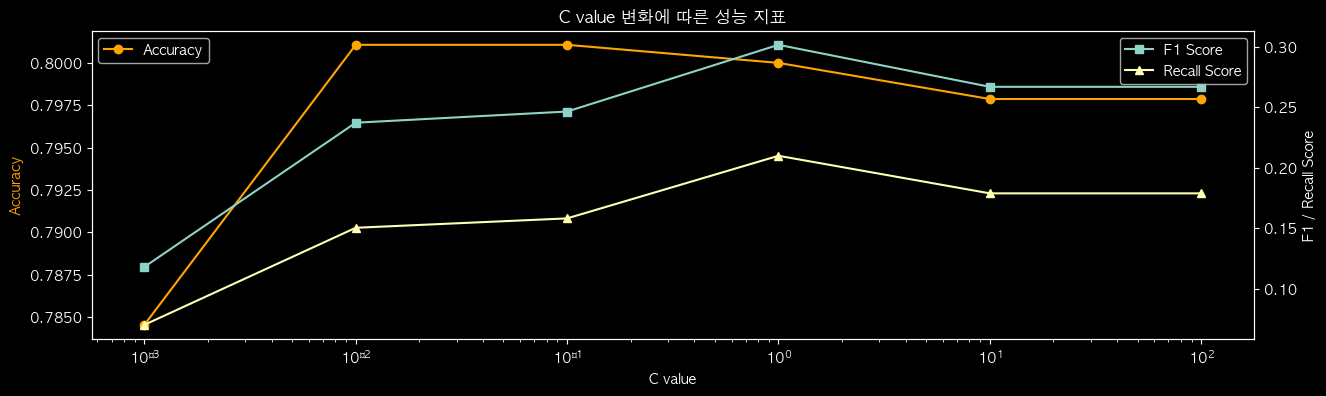

In [4]:
plt.figure(figsize=(15, 4))
ax1 = plt.gca()
ax2 = ax1.twinx() 

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

ax1.plot(C_values, Acc_scores, label='Accuracy', color='orange', marker='o')
ax2.plot(C_values, f1_scores, label='F1 Score', marker='s')
ax2.plot(C_values, recall_scores, label='Recall Score', marker='^')

ax1.set_xscale('log')
ax1.set_xlabel('C value')
ax1.set_ylabel('Accuracy', color='orange')
ax2.set_ylabel('F1 / Recall Score')
ax1.set_title('C value 변화에 따른 성능 지표')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# 최종 선정 0.1

In [7]:
# 최종 모델
final_model = LogisticRegression(random_state=42, C=0.1)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
precision = precision_score(y_test, final_pred)

print(f"최종 모델 성능 - Accuracy: {final_accuracy:.4f}, F1 Score: {final_f1:.4f}, Recall: {final_recall:.4f}, Precision: {precision:.4f}")
# 최종 모델 성능 - Accuracy: 0.7976, F1 Score: 0.1481, Recall: 0.0885
# 높은 정확도는 착시
# recall, f1 score가 너무 낮음

최종 모델 성능 - Accuracy: 0.8124, F1 Score: 0.2883, Recall: 0.1911, Precision: 0.5864


/Users/tera/Desktop/workspace/skn_21/project/project_02/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
